In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [ ]:
df=pd.read_csv("diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    50000 non-null  float64
 1   cut      50000 non-null  object 
 2   color    50000 non-null  object 
 3   clarity  50000 non-null  object 
 4   depth    50000 non-null  float64
 5   table    50000 non-null  float64
 6   price    50000 non-null  int64  
 7   x        50000 non-null  float64
 8   y        50000 non-null  float64
 9   z        50000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.8+ MB


In [ ]:
df.shape

(50000, 10)

In [ ]:
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(126)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
Q1=df["price"].quantile(0.25)
Q3=df["price"].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
df=df[(df["price"]>=lower)&(df["price"]<=upper)]

In [ ]:
df.describe()

,carat,depth,table,price,x,y,z
count,46619.000000,46619.000000,46619.000000,46619.000000,46619.000000,46619.000000,46619.000000
mean,0.725291,61.759169,57.423040,3175.098308,5.586895,5.590348,3.451087
std,0.384687,1.426946,2.225699,2780.373023,0.995841,0.995391,0.632020
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.380000,61.100000,56.000000,911.000000,4.670000,4.680000,2.880000
50%,0.700000,61.800000,57.000000,2168.000000,5.600000,5.590000,3.440000
75%,1.010000,62.500000,59.000000,4687.000000,6.430000,6.430000,3.990000
max,3.650000,79.000000,79.000000,11951.000000,9.540000,31.800000,31.800000


In [ ]:
df["price"].mean()

np.float64(3175.098307557005)

In [ ]:
df["price"].median()

2168.0

In [ ]:
df["price"].mode()

,price
0,802


In [ ]:
df["price"].std()

2780.3730232946477

In [ ]:
df["price"].var()

7730474.14866462

In [ ]:
df.select_dtypes(include=np.number).describe()

,carat,depth,table,price,x,y,z
count,46619.000000,46619.000000,46619.000000,46619.000000,46619.000000,46619.000000,46619.000000
mean,0.725291,61.759169,57.423040,3175.098308,5.586895,5.590348,3.451087
std,0.384687,1.426946,2.225699,2780.373023,0.995841,0.995391,0.632020
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.380000,61.100000,56.000000,911.000000,4.670000,4.680000,2.880000
50%,0.700000,61.800000,57.000000,2168.000000,5.600000,5.590000,3.440000
75%,1.010000,62.500000,59.000000,4687.000000,6.430000,6.430000,3.990000
max,3.650000,79.000000,79.000000,11951.000000,9.540000,31.800000,31.800000


In [ ]:
df["cut"].value_counts()

,count
cut,
Ideal,18826
Premium,11595
Very Good,10497
Good,4301
Fair,1400


In [ ]:
df["color"].value_counts()

,count
color,
G,9751
E,8728
F,8372
H,7070
D,5965
I,4457
J,2276


In [ ]:
df["clarity"].value_counts()

,count
clarity,
SI1,11370
VS2,10588
SI2,7572
VS1,7136
VVS2,4490
VVS1,3254
IF,1535
I1,674


In [ ]:
df.select_dtypes(include=np.number).corr()

,carat,depth,table,price,x,y,z
carat,1.000000,0.047865,0.184906,0.915734,0.980865,0.972487,0.954848
depth,0.047865,1.000000,-0.291076,0.003887,-0.014705,-0.018189,0.116077
table,0.184906,-0.291076,1.000000,0.130073,0.194236,0.185339,0.145481
price,0.915734,0.003887,0.130073,1.000000,0.895866,0.891038,0.868160
x,0.980865,-0.014705,0.194236,0.895866,1.000000,0.990217,0.964336
y,0.972487,-0.018189,0.185339,0.891038,0.990217,1.000000,0.957877
z,0.954848,0.116077,0.145481,0.868160,0.964336,0.957877,1.000000


Histogram


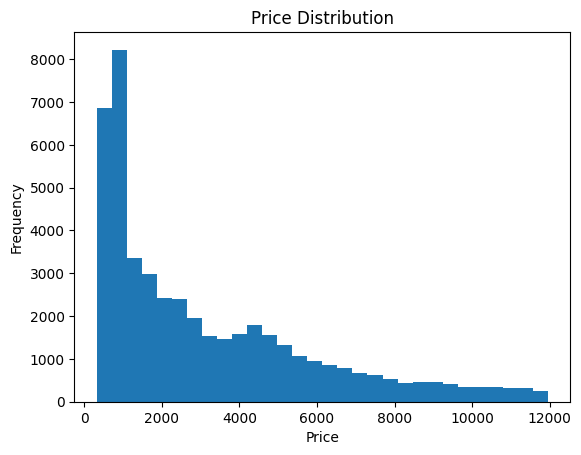

In [ ]:
plt.hist(df["price"],bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Scatter plot


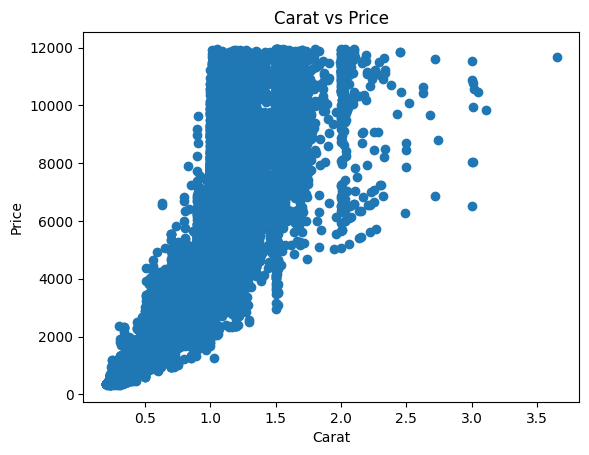

In [ ]:
plt.scatter(df["carat"],df["price"])
plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.show()

Box plot


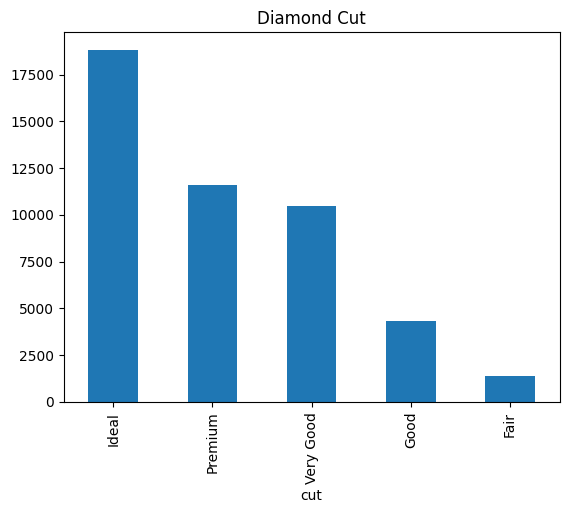

In [ ]:
df["cut"].value_counts().plot(kind="bar")
plt.title("Diamond Cut")
plt.show()